In [4]:
import glob
import json
import os

from dotenv import load_dotenv
# use pip install "labelbox[data]"
import labelbox

from koger_detection.labelbox.annotations import download_annotation_projects
from koger_detection.utils.json import create_train_val_split, create_json_from_image_names

# Load local .env file that contains local path "ROOT" and "LABELBOX_API_KEY"
load_dotenv()

True

In [2]:
os.environ.get("PROJECT_ROOT")

client = labelbox.Client(api_key=os.environ.get("LABELBOX_API_KEY"))

project_names = ["salmon-tlc"]

annotation_folder = os.path.join(os.environ.get("PROJECT_ROOT"), "annotations")

In [3]:
if True:
    download_annotation_projects(annotation_folder, client, project_names, 
                                 verbose=True, download_images=True, 
                                 skip_existing=True)


Data Rows Converted into a COCO Dataset.

Converting Annotations into the COCO Format...



1751it [00:00, 591037.04it/s]


Annotation Conversion Complete. Converted 1751 annotations into the COCO Format.

Converting the Ontology into the COCO Dataset Format...

Ontology Conversion Complete

COCO Conversion Complete


Annotation file downloaded.
Starting to save 1061 images.


In [ ]:
# Put all images that weren't in old test set into train

val_file = os.path.join(annotation_folder, "val-01.json")
val_anns = json.load(open(val_file))
val_image_names = set([item["file_name"] for item in val_anns['images']])

all_anns = json.load(open(os.path.join(annotation_folder, "salmon-tlc.json")))
all_image_names = set([item["file_name"] for item in all_anns['images']])
all_image_ids = set([item["id"] for item in all_anns['images']])

train_image_names = []
train_image_ids = []
new_val_image_names = []

for image_name, image_id in zip(all_image_names, all_image_ids):
    if image_name not in val_image_names:
        train_image_names.append(image_name)
        train_image_ids.append(image_id)
    else:
        new_val_image_names.append(image_name)

assert

print(f"train: {len(train_image_names)}, val: {len(new_val_image_names)}")
print(f"{len(val_image_names)}")

create_json_from_image_names(train_image_ids, all_anns, os.path.join(annotation_folder, "train-02.json"))




train: 878, val: 183
183


In [14]:
print("hi")

hi


### Split annotations into train and val set

In [7]:
json_file = os.path.join(annotation_folder, "salmon-tlc.json")
fraction_val = .25
create_train_val_split(json_file, fraction_val, train_name="train.json", 
                       val_name="val.json")

There are 732 annotated images.
549 training images with 911 annotations.
183 validation images with 300 annotations.


### Visualize annotations

In [8]:
import os

import matplotlib.pyplot as plt

import torch
# Note: also need to install pycocotools
from torchvision import datasets
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_convert
import torchvision.transforms.functional as F

In [13]:
example_json = os.path.join(annotation_folder, f"val.json")
image_folder = os.path.join(annotation_folder, "images")

dataset = datasets.CocoDetection(root=image_folder, annFile=example_json)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


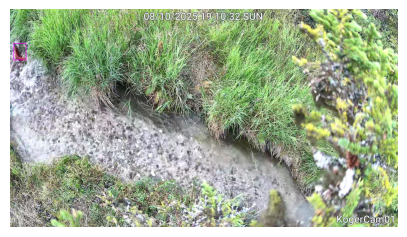

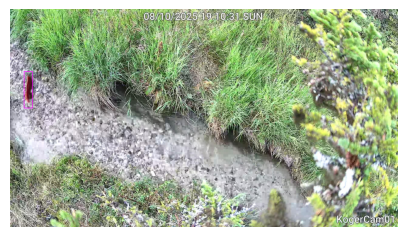

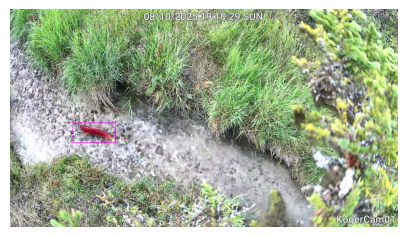

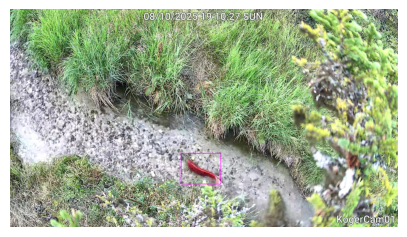

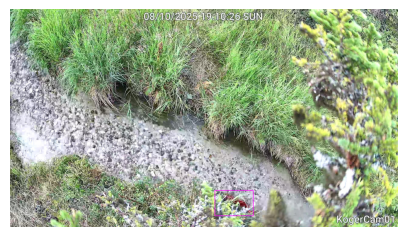

In [14]:
for im_ind in range(0, 5):
    ann = dataset[im_ind]
    if len(ann[1]) >= 1:
        boxes = torch.vstack([box_convert(torch.tensor(a['bbox']), "xywh", "xyxy") for a in ann[1]])
        labels = [a['category_id'] for a in ann[1]]
        colors = [(230,215,255), (255, 255, 0), (255, 0, 255), (255, 155, 0), (255, 0, 155),(255, 155, 155), (255, 255, 155)]
        box_colors = [colors[l-1] for l in labels]
    image = F.pil_to_tensor(ann[0])
    if len(ann[1]) >= 1:
        image = draw_bounding_boxes((image).type(torch.uint8), 
                                      boxes=boxes, colors=box_colors,
                                      width=4)
    else:
        print("No annotations")
    plt.figure(figsize=(5, 5))
    plt.imshow(F.to_pil_image(image))
    plt.axis('off')  